Я буду тестировать каждое преобразование отдельно и сравнивать с бейслайном, затем выберу только лучшие и скомбинирую их

## Импорт библиотек

In [1]:
# Необходимо для корректной работы внешних .py файлов
%load_ext autoreload
%autoreload 2

In [ ]:
import random
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from category_encoders import OrdinalEncoder, CatBoostEncoder
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from helper import divide_data, train_evaluate_models_cv
from plots import compare_metrics_heatmap, plot_hist_numeric, plot_hist_categorical

In [ ]:
# фиксируем состояние генератора псевдослучайных чисел.
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

## 1. Препроцессинг данных

In [4]:
NUMERICAL_FEATURES_LIST = ["tenure", "MonthlyCharges", "TotalCharges"]

CATEGORICAL_FEATURES_LIST = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
]

TARGET = "Churn"

In [ ]:
CATEGORICAL_WITHOUT_SENIOR = [
    col for col in CATEGORICAL_FEATURES_LIST if col != "SeniorCitizen"
]

CATEGORICAL_ORDINAL_ENC = [
    col
    for col in CATEGORICAL_WITHOUT_SENIOR
    if col not in ["gender", "InternetService", "PaymentMethod"]
]

ordinal_mapping = [
    {'col': 'Partner', 'mapping': {'No': 0, 'Yes': 1}},
    {'col': 'Dependents', 'mapping': {'No': 0, 'Yes': 1}},
    {'col': 'PhoneService', 'mapping': {'No': 0, 'Yes': 1}},
    {'col': 'MultipleLines', 'mapping': {'No phone service': 0, 'No': 1, 'Yes': 2}},
    {'col': 'OnlineSecurity', 'mapping': {'No internet service': 0, 'No': 1, 'Yes': 2}},
    {'col': 'OnlineBackup', 'mapping': {'No internet service': 0, 'No': 1, 'Yes': 2}},
    {'col': 'DeviceProtection', 'mapping': {'No internet service': 0, 'No': 1, 'Yes': 2}},
    {'col': 'TechSupport', 'mapping': {'No internet service': 0, 'No': 1, 'Yes': 2}},
    {'col': 'StreamingTV', 'mapping': {'No internet service': 0, 'No': 1, 'Yes': 2}},
    {'col': 'StreamingMovies', 'mapping': {'No internet service': 0, 'No': 1, 'Yes': 2}},
    {'col': 'Contract', 'mapping': {'Month-to-month': 0, 'One year': 1, 'Two year': 2}},
    {'col': 'PaperlessBilling', 'mapping': {'No': 0, 'Yes': 1}}
]

CATEGORICAL_CATBOOST_ENC = ["gender", "InternetService", "PaymentMethod"]

In [ ]:
preprocessor = ColumnTransformer(
    [
        # Числовые признаки: скалирование
        ("scaler_numerical", StandardScaler(), NUMERICAL_FEATURES_LIST),
        # Порядковые категориальные признаки
        (
            "ordinal_categorical",
            OrdinalEncoder(
                cols=CATEGORICAL_ORDINAL_ENC,
                mapping=ordinal_mapping,
                handle_unknown="value",
                handle_missing="value",
            ),
            CATEGORICAL_ORDINAL_ENC,
        ),
        # Категориальные признаки для CatBoost Encoding
        (
            "catboost_categorical",
            CatBoostEncoder(
                cols=CATEGORICAL_CATBOOST_ENC,
                sigma=None,
                a=1.0,
                handle_unknown="value",
                handle_missing="value",
                random_state=42,
            ),
            CATEGORICAL_CATBOOST_ENC,
        ),
    ],
    remainder="passthrough",  # колонки, не указанные в трансформерах, передаются без изменений
    verbose_feature_names_out=False,  # не добавлять префиксы к именам колонок
)

# Устанавливаем вывод в формате pandas DataFrame
preprocessor.set_output(transform="pandas")

,transformers,"[('scaler_numerical', ...), ('ordinal_categorical', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [7]:
df = pd.read_csv("./Telecom_Customer_Churn.csv")

In [8]:
df_preprocessed = df.copy()
df_preprocessed = df_preprocessed.drop(columns=['customerID'])
df_preprocessed["TotalCharges"] = pd.to_numeric(df_preprocessed["TotalCharges"], errors="coerce")
df_preprocessed["TotalCharges"] = df_preprocessed["TotalCharges"].fillna(0)
df_preprocessed[TARGET] = np.where(df_preprocessed[TARGET] == 'Yes', 1, 0)

In [9]:
X, y = divide_data(df_preprocessed, TARGET)

In [10]:
# сохраним все бейслайн модели в виде списка для удобства
models = [
    ('Logistic Regression', LogisticRegression(random_state=SEED, max_iter=1000, solver='liblinear')),
    ('DecisionTreeClassifier', DecisionTreeClassifier(random_state=SEED, max_depth=4)),
    ('RandomForestClassifier', RandomForestClassifier(random_state=SEED)),
    ('LGBMClassifier', LGBMClassifier(random_state=SEED)),
    ('CatBoostClassifier', CatBoostClassifier(random_state=SEED, verbose=0, task_type="CPU", allow_writing_files=False))
]

In [11]:
# используем 5-блочную кросс-валидацию, учитывающую распределение таргета при разбиении
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000328 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1383
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000406 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1383
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 19
[LightGBM] [Info] [binar

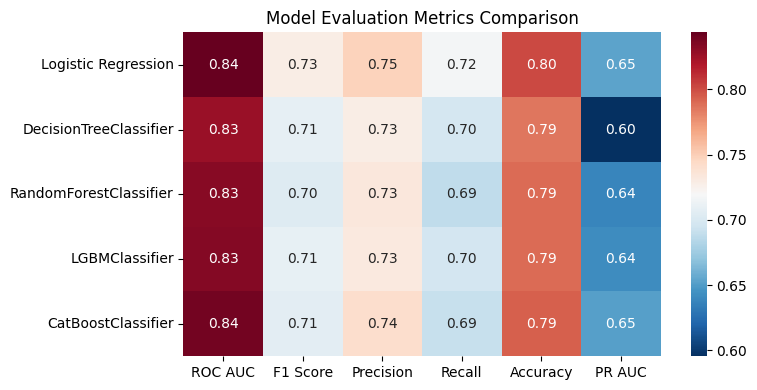

In [ ]:
# Исходные метрики
initial_metrics = train_evaluate_models_cv(
    models=models,
    X=X,
    y=y,
    preprocessor=preprocessor,
    cv=cv,
    seed=SEED
)

## 2. Преобразования данных и feature engineering

### 2.1 Логарифмическое преобразование TotalCharges

#### 2.1.1 Без удаления столбцов

In [13]:
X_log = X.copy()

In [14]:
X_log['TotalChargesLog'] = np.log1p(X_log['TotalCharges'])

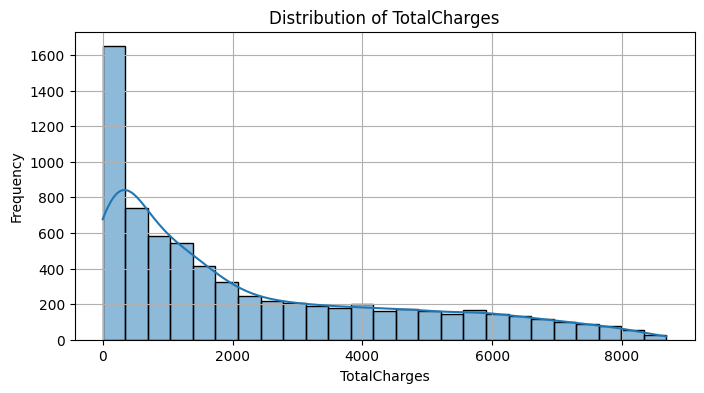

In [15]:
plot_hist_numeric(X_log, 'TotalCharges')

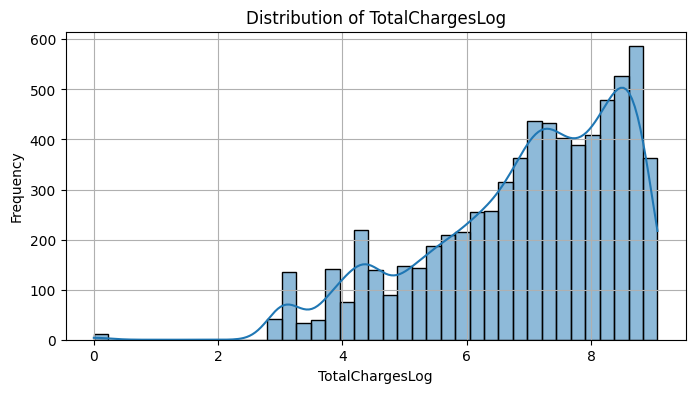

In [16]:
plot_hist_numeric(X_log, 'TotalChargesLog')

In [17]:
preprocessor_log = clone(preprocessor)
preprocessor_log.transformers[0][2].append('TotalChargesLog')

[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000424 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1638
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000215 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1638
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGB

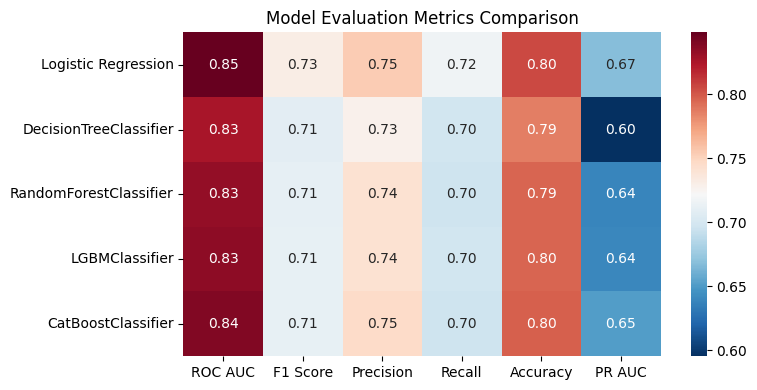

In [18]:
log_metrics = train_evaluate_models_cv(
    models=models,
    X=X_log,
    y=y,
    preprocessor=preprocessor_log,
    cv=cv,
    seed=SEED
)

(<Figure size 800x400 with 2 Axes>,
                          ROC AUC  F1 Score  Precision    Recall  Accuracy  \
 Logistic Regression     0.534179  0.246491   0.875400 -0.056739  0.425275   
 DecisionTreeClassifier  0.000000  0.000000   0.000000  0.000000  0.000000   
 RandomForestClassifier  0.093746  1.048025   1.012521  1.037329  0.628841   
 LGBMClassifier          0.095785  0.405703   1.293284  0.093768  0.628833   
 CatBoostClassifier     -0.017347  0.723768   0.587885  0.713972  0.375507   
 
                           PR AUC  
 Logistic Regression     2.261538  
 DecisionTreeClassifier  0.000000  
 RandomForestClassifier  0.020919  
 LGBMClassifier         -0.290320  
 CatBoostClassifier      0.037702  )

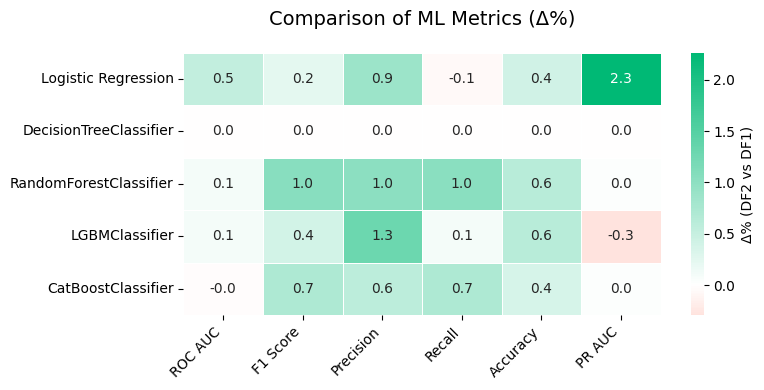

In [19]:
# сравним изначальные метрики с метриками после логарифмирования
compare_metrics_heatmap(initial_metrics, log_metrics)

Метрики немного улучшились

#### 2.1.2 С удалением исходных столбцов

In [20]:
X_log_delete = X.copy()

In [21]:
X_log_delete['TotalCharges'] = np.log1p(X_log_delete['TotalCharges'])

[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000288 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1383
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000224 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1383
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 19
[LightGBM] [Info] [binar

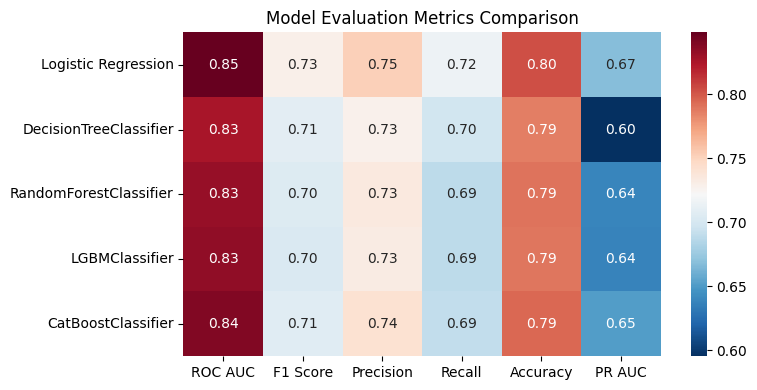

In [22]:
log_delete_metrics = train_evaluate_models_cv(
    models=models,
    X=X_log_delete,
    y=y,
    preprocessor=preprocessor,
    cv=cv,
    seed=SEED
)

(<Figure size 800x400 with 2 Axes>,
                          ROC AUC  F1 Score  Precision    Recall  Accuracy  \
 Logistic Regression     0.531590  0.072767   0.589473 -0.178005  0.265887   
 DecisionTreeClassifier  0.000000  0.000000   0.000000  0.000000  0.000000   
 RandomForestClassifier  0.005218  0.119300   0.098193  0.116775  0.053941   
 LGBMClassifier         -0.034453 -0.836831   0.028491 -1.116042 -0.143536   
 CatBoostClassifier      0.000740  0.000000   0.000000  0.000000  0.000000   
 
                           PR AUC  
 Logistic Regression     2.322413  
 DecisionTreeClassifier  0.000000  
 RandomForestClassifier  0.010918  
 LGBMClassifier         -0.588006  
 CatBoostClassifier      0.001419  )

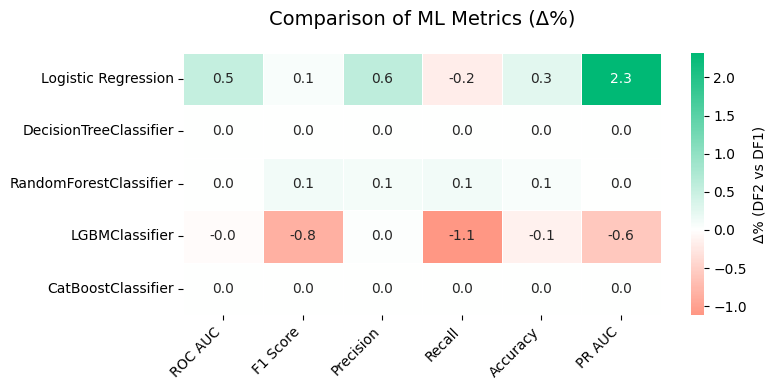

In [23]:
compare_metrics_heatmap(initial_metrics, log_delete_metrics)

После удаления изначального столбца метрики практически не изменились, кроме немного выросшего pr_auc у логистической регресии

### 2.2 Биннинг для tenure
tenure_bins - разбить клиентов по количеству месяцов с компанией: 0-12 мес = 'Новичок', 13-60 = '1–5 лет', >60 мес

#### 2.2.1 Без удаления

In [29]:
X_tenure_binning = X.copy()

In [30]:
bins = [-np.inf, 12, 60, np.inf]
labels = [0, 1, 2]

X_tenure_binning['tenure_bins'] = pd.cut(X_tenure_binning['tenure'], bins=bins, labels=labels).astype(int)

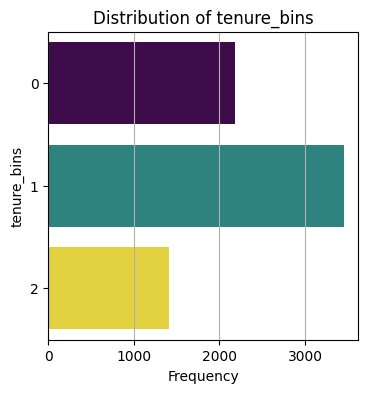

In [31]:
plot_hist_categorical(X_tenure_binning, 'tenure_bins')

[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000252 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1386
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000553 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1386
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGB

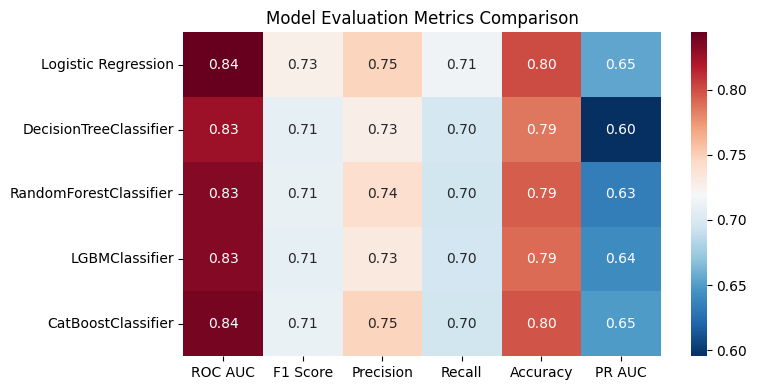

In [55]:
tenure_binning_metrics = train_evaluate_models_cv(
    models=models,
    X=X_tenure_binning,
    y=y,
    preprocessor=preprocessor,
    cv=cv,
    seed=SEED
)

(<Figure size 800x400 with 2 Axes>,
                          ROC AUC  F1 Score  Precision    Recall  Accuracy  \
 Logistic Regression     0.027678 -0.282056  -0.108994 -0.366469 -0.106272   
 DecisionTreeClassifier  0.000000  0.000000   0.000000  0.000000  0.000000   
 RandomForestClassifier  0.165064  1.059427   0.945996  1.045737  0.575117   
 LGBMClassifier          0.000000  0.000000   0.000000  0.000000  0.000000   
 CatBoostClassifier     -0.024036  0.740984   0.865137  0.625388  0.482874   
 
                           PR AUC  
 Logistic Regression     0.152571  
 DecisionTreeClassifier  0.000000  
 RandomForestClassifier -0.608501  
 LGBMClassifier          0.000000  
 CatBoostClassifier     -0.191154  )

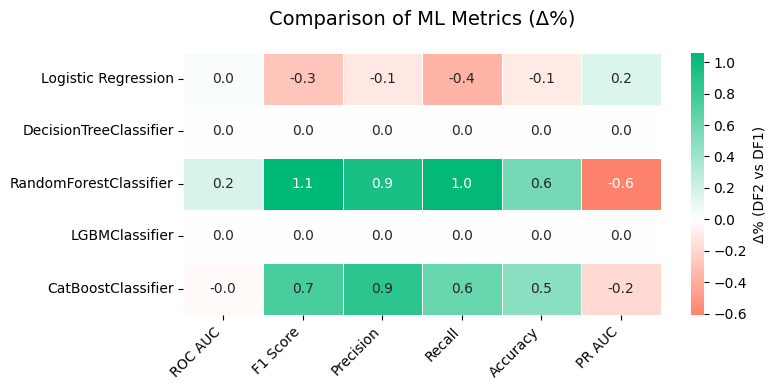

In [56]:
compare_metrics_heatmap(initial_metrics, tenure_binning_metrics)

Метрики, кроме pr_auc и roc_auc, немного улучшились у Случайного леса и Catboost

#### 2.2.2 С удалением

In [57]:
X_tenure_binning_del = X.copy()

In [58]:
bins = [-np.inf, 12, 60, np.inf]
labels = [0, 1, 2]

X_tenure_binning_del['tenure_bins'] = pd.cut(X_tenure_binning_del['tenure'], bins=bins, labels=labels).astype(int)
X_tenure_binning_del = X_tenure_binning_del.drop(columns=['tenure'])

In [59]:
preprocessor_tenure_binning_del = clone(preprocessor)
preprocessor_tenure_binning_del.transformers[0][2].remove("tenure")

[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000276 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1312
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000312 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1312
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 19
[LightGBM] [Info] [binar

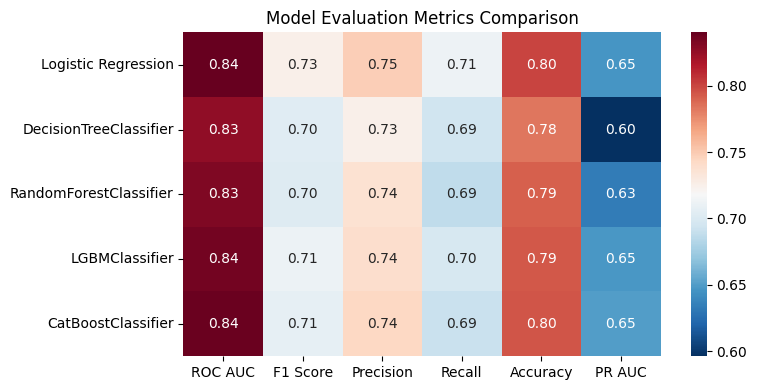

In [60]:
tenure_binning_del_metrics = train_evaluate_models_cv(
    models=models,
    X=X_tenure_binning_del,
    y=y,
    preprocessor=preprocessor_tenure_binning_del,
    cv=cv,
    seed=SEED,
)

(<Figure size 800x400 with 2 Axes>,
                          ROC AUC  F1 Score  Precision    Recall  Accuracy  \
 Logistic Regression    -0.385799 -0.511599   0.045455 -0.757402 -0.088511   
 DecisionTreeClassifier  0.059432 -0.663707  -0.366156 -0.580426 -0.342962   
 RandomForestClassifier -0.001385 -0.077680   0.409509 -0.182226  0.179498   
 LGBMClassifier          0.270016  0.348369   1.038076  0.131674  0.521066   
 CatBoostClassifier     -0.001759  0.141257   0.359277  0.040956  0.178662   
 
                           PR AUC  
 Logistic Regression    -1.055576  
 DecisionTreeClassifier  0.103911  
 RandomForestClassifier -0.751944  
 LGBMClassifier          0.935661  
 CatBoostClassifier     -0.184300  )

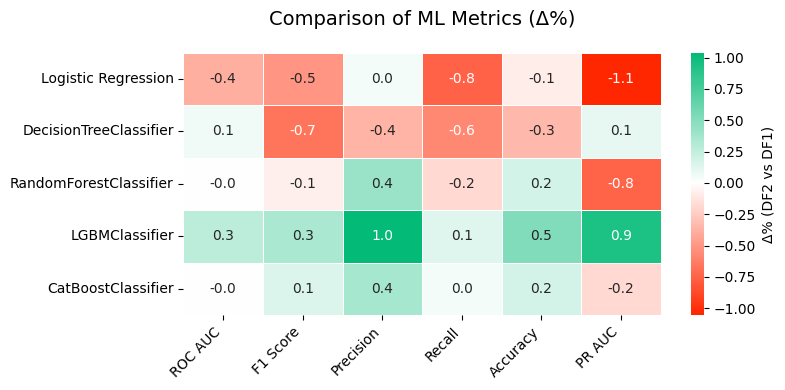

In [61]:
compare_metrics_heatmap(initial_metrics, tenure_binning_del_metrics)

(<Figure size 800x400 with 2 Axes>,
                          ROC AUC  F1 Score  Precision    Recall  Accuracy  \
 Logistic Regression    -0.413362 -0.230191   0.154618 -0.392371  0.017779   
 DecisionTreeClassifier  0.059432 -0.663707  -0.366156 -0.580426 -0.342962   
 RandomForestClassifier -0.166174 -1.125186  -0.531459 -1.215255 -0.393357   
 LGBMClassifier          0.270016  0.348369   1.038076  0.131674  0.521066   
 CatBoostClassifier      0.022282 -0.595316  -0.501521 -0.580799 -0.302750   
 
                           PR AUC  
 Logistic Regression    -1.206306  
 DecisionTreeClassifier  0.103911  
 RandomForestClassifier -0.144322  
 LGBMClassifier          0.935661  
 CatBoostClassifier      0.006868  )

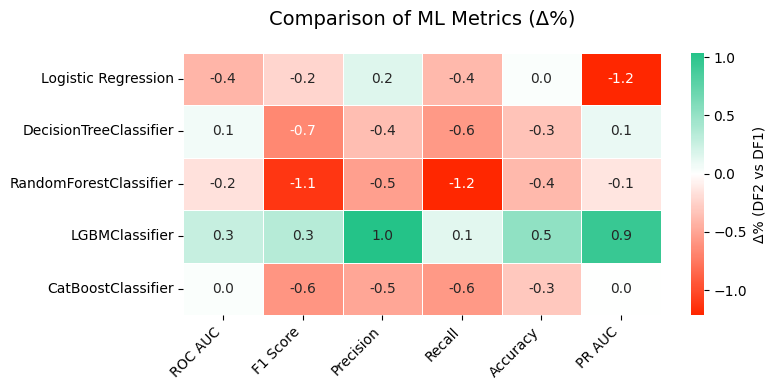

In [62]:
compare_metrics_heatmap(tenure_binning_metrics, tenure_binning_del_metrics)

После удаления tenure метрики немного улучшились только у LDBMClassifier, у остальных моделей метрики ухудшились

### 2.3 Биннинг для MonthlyCharges
monthly_charges_bins - разбить клиентов по сумме ежемесячной оплаты: <30, 30-70, >70

#### 2.3.1 Без удаления

In [63]:
X_monthly_charges_binning = X.copy()

In [64]:
bins = [-np.inf, 30, 70, np.inf]
labels = [0, 1, 2]

X_monthly_charges_binning['monthly_charges_bins'] = pd.cut(X_monthly_charges_binning['MonthlyCharges'], bins=bins, labels=labels).astype(int)

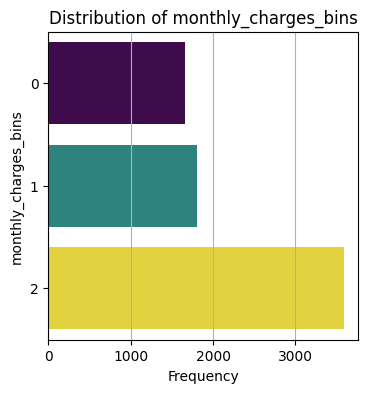

In [65]:
plot_hist_categorical(X_monthly_charges_binning, 'monthly_charges_bins')

[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000237 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1386
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000685 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1386
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGB

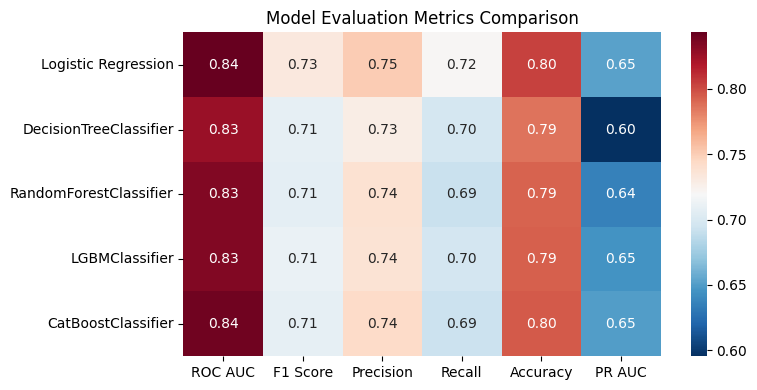

In [66]:
monthly_charges_binning_metrics = train_evaluate_models_cv(
    models=models,
    X=X_monthly_charges_binning,
    y=y,
    preprocessor=preprocessor,
    cv=cv,
    seed=SEED
)

(<Figure size 800x400 with 2 Axes>,
                          ROC AUC  F1 Score  Precision    Recall  Accuracy  \
 Logistic Regression    -0.040605  0.457063   0.409686  0.464460  0.265723   
 DecisionTreeClassifier  0.000000  0.000000   0.000000  0.000000  0.000000   
 RandomForestClassifier  0.241479  0.594277   0.555378  0.540567  0.341398   
 LGBMClassifier          0.105322  0.252871   0.767124 -0.002673  0.377364   
 CatBoostClassifier      0.080201  0.256342   0.254721  0.211308  0.143148   
 
                           PR AUC  
 Logistic Regression    -0.120522  
 DecisionTreeClassifier  0.000000  
 RandomForestClassifier -0.414236  
 LGBMClassifier          0.693292  
 CatBoostClassifier     -0.109343  )

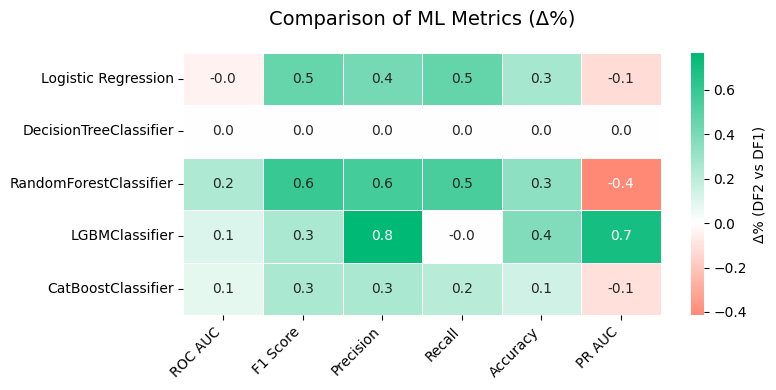

In [67]:
compare_metrics_heatmap(initial_metrics, monthly_charges_binning_metrics)

Небольшое улучшение метрик почти у всех моделей

#### 2.3.2 С удалением

In [68]:
X_monthly_charges_binning_del = X.copy()

In [69]:
bins = [-np.inf, 30, 70, np.inf]
labels = [0, 1, 2]

X_monthly_charges_binning_del['monthly_charges_bins'] = pd.cut(X_monthly_charges_binning_del['MonthlyCharges'], bins=bins, labels=labels).astype(int)
X_monthly_charges_binning_del = X_monthly_charges_binning_del.drop(columns=['MonthlyCharges'])

In [70]:
preprocessor_monthly_charges_binning_del = clone(preprocessor)
preprocessor_monthly_charges_binning_del.transformers[0][2].remove("MonthlyCharges")

[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000266 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1131
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000423 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1131
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 19
[LightGBM] [Info] [binar

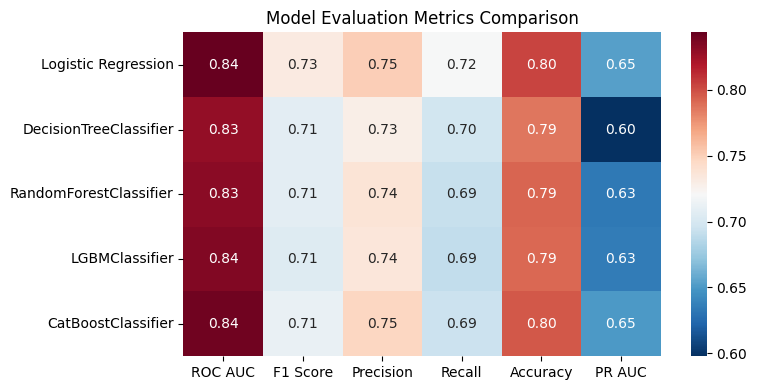

In [71]:
monthly_charges_binning_del_metrics = train_evaluate_models_cv(
    models=models,
    X=X_monthly_charges_binning_del,
    y=y,
    preprocessor=preprocessor_monthly_charges_binning_del,
    cv=cv,
    seed=SEED
)

(<Figure size 800x400 with 2 Axes>,
                          ROC AUC  F1 Score  Precision    Recall  Accuracy  \
 Logistic Regression     0.014014  0.423894   0.380859  0.426960  0.247950   
 DecisionTreeClassifier  0.352541  0.002152   0.032058 -0.010627  0.018052   
 RandomForestClassifier  0.018365  0.621866   0.532874  0.625817  0.323494   
 LGBMClassifier          0.167358 -0.540668   0.553655 -0.894757  0.143996   
 CatBoostClassifier      0.146421  0.673497   0.849935  0.499136  0.447119   
 
                           PR AUC  
 Logistic Regression    -0.077733  
 DecisionTreeClassifier  0.378419  
 RandomForestClassifier -0.848644  
 LGBMClassifier         -1.042707  
 CatBoostClassifier     -0.096309  )

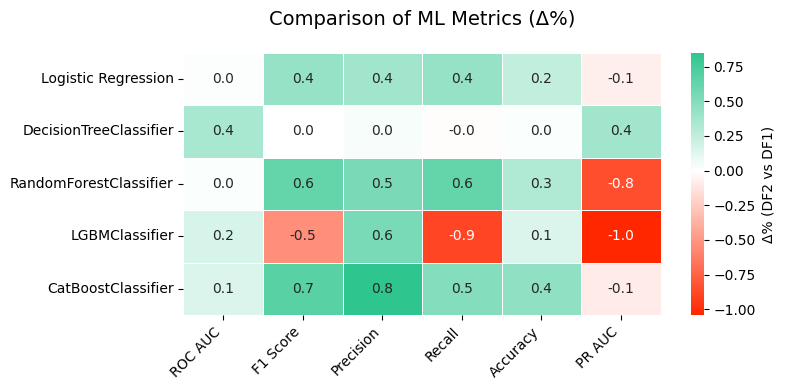

In [72]:
compare_metrics_heatmap(initial_metrics, monthly_charges_binning_del_metrics)

(<Figure size 800x400 with 2 Axes>,
                          ROC AUC  F1 Score  Precision    Recall  Accuracy  \
 Logistic Regression     0.054641 -0.033018  -0.028709 -0.037327 -0.017726   
 DecisionTreeClassifier  0.352541  0.002152   0.032058 -0.010627  0.018052   
 RandomForestClassifier -0.222576  0.027425  -0.022379  0.084792 -0.017843   
 LGBMClassifier          0.061971 -0.791538  -0.211844 -0.892108 -0.232491   
 CatBoostClassifier      0.066167  0.416088   0.593702  0.287221  0.303536   
 
                           PR AUC  
 Logistic Regression     0.042840  
 DecisionTreeClassifier  0.378419  
 RandomForestClassifier -0.436216  
 LGBMClassifier         -1.724047  
 CatBoostClassifier      0.013048  )

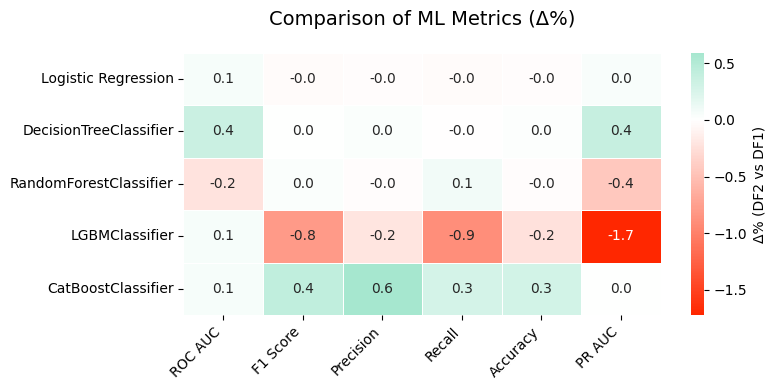

In [73]:
compare_metrics_heatmap(monthly_charges_binning_metrics, monthly_charges_binning_del_metrics)

Удаление MonthlyCharges не улучшило метрики

### 2.4 Создание нового признака NumInternetService
Количество подключенных интернет услуг

In [74]:
X_num_internet_service = X.copy()

In [75]:
X_num_internet_service["NumInternetService"] = (
    (df["OnlineSecurity"] == "Yes").astype(int)
    + (df["OnlineBackup"] == "Yes").astype(int)
    + (df["DeviceProtection"] == "Yes").astype(int)
    + (df["TechSupport"] == "Yes").astype(int)
    + (df["StreamingTV"] == "Yes").astype(int)
    + (df["StreamingMovies"] == "Yes").astype(int)
)

[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000288 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1390
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000284 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1390
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 20
[LightGBM] [Info] [binar

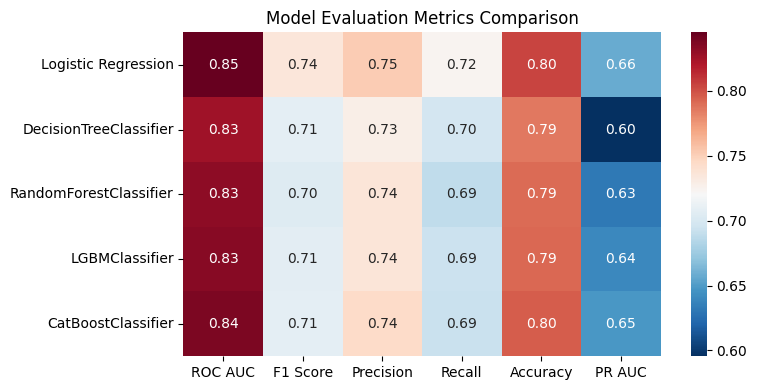

In [77]:
num_internet_service_metrics = train_evaluate_models_cv(
    models=models,
    X=X_num_internet_service,
    y=y,
    preprocessor=preprocessor,
    cv=cv,
    seed=SEED,
)

(<Figure size 800x400 with 2 Axes>,
                          ROC AUC  F1 Score  Precision    Recall  Accuracy  \
 Logistic Regression     0.187711  0.810393   0.578319  0.905796  0.407414   
 DecisionTreeClassifier  0.000000  0.000000   0.000000  0.000000  0.000000   
 RandomForestClassifier -0.013626  0.103606   0.325860  0.002965  0.161555   
 LGBMClassifier          0.022586 -0.213390   0.629606 -0.516959  0.251546   
 CatBoostClassifier     -0.103681  0.253295   0.447928  0.181622  0.232511   
 
                           PR AUC  
 Logistic Regression     0.695772  
 DecisionTreeClassifier  0.000000  
 RandomForestClassifier -1.101684  
 LGBMClassifier         -0.145555  
 CatBoostClassifier     -0.540523  )

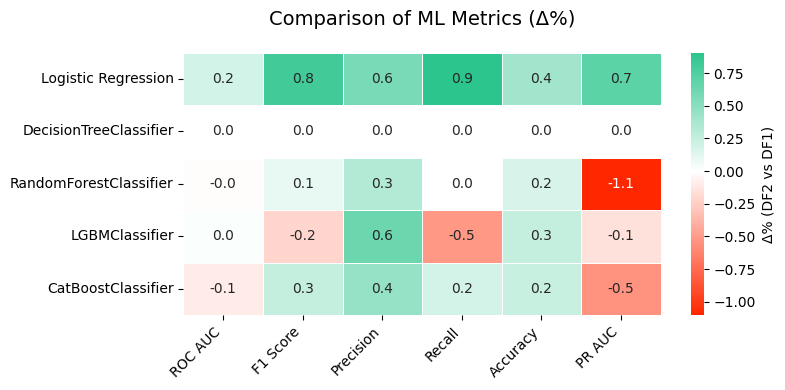

In [78]:
compare_metrics_heatmap(initial_metrics, num_internet_service_metrics)

Небольшие улучшения, в основном у Логистической регрессии

### 2.5 Удаление StandardScaler


In [81]:
preprocessor.transformers[0]

('scaler_numerical',
 StandardScaler(),
 ['tenure', 'MonthlyCharges', 'TotalCharges'])

In [82]:
X_standard_scaler_del = X.copy()

In [83]:
preprocessor_standard_scaler_del = clone(preprocessor)
del preprocessor_standard_scaler_del.transformers[0]

[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000293 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1382
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000278 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1382
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 19
[LightGBM] [Info] [binar

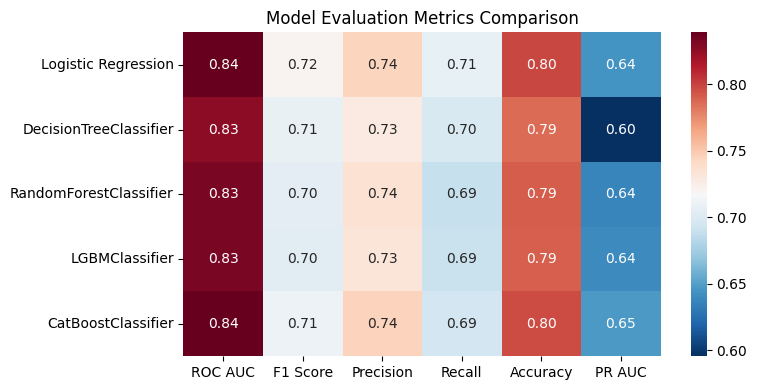

In [84]:
standard_scaler_del_metrics = train_evaluate_models_cv(
    models=models,
    X=X_standard_scaler_del,
    y=y,
    preprocessor=preprocessor_standard_scaler_del,
    cv=cv,
    seed=SEED,
)

(<Figure size 800x400 with 2 Axes>,
                          ROC AUC  F1 Score  Precision    Recall  Accuracy  \
 Logistic Regression    -0.548417 -1.113841  -0.395481 -1.392049 -0.389780   
 DecisionTreeClassifier  0.000000  0.000000   0.000000  0.000000  0.000000   
 RandomForestClassifier  0.087543  0.160480   0.291353  0.126200  0.161466   
 LGBMClassifier         -0.056791 -0.793072   0.143797 -1.010256 -0.035808   
 CatBoostClassifier     -0.040712  0.540961   0.510687  0.509795  0.304022   
 
                           PR AUC  
 Logistic Regression    -1.316700  
 DecisionTreeClassifier  0.000000  
 RandomForestClassifier -0.158252  
 LGBMClassifier         -0.271501  
 CatBoostClassifier     -0.513918  )

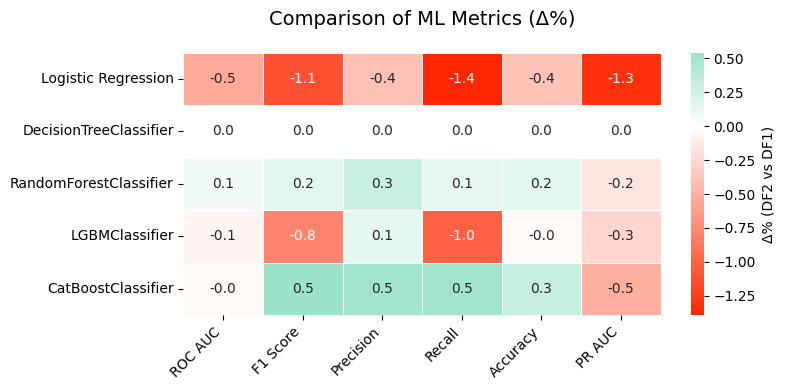

In [85]:
compare_metrics_heatmap(initial_metrics, standard_scaler_del_metrics)

Удаление StandardScaler немного улучшило метрики для Catboost, для Регрессии метрики ухудшились.

### 2.6 Замена StandardScaler на MinMaxScaler (нормализация)

In [93]:
X_normalized = X.copy()

In [94]:
preprocessor_normalization = clone(preprocessor)
preprocessor_normalization.transformers[0] = ('scaler', MinMaxScaler(), NUMERICAL_FEATURES_LIST)

[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000475 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1382
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000677 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1382
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
[LightGBM] [Info] 

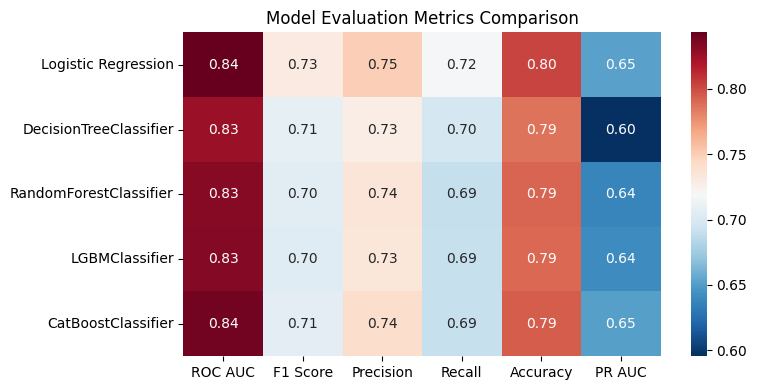

In [96]:
normalised_metrics = train_evaluate_models_cv(
    models=models,
    X=X_normalized,
    y=y,
    preprocessor=preprocessor_normalization,
    cv=cv,
    seed=SEED
)

(<Figure size 800x400 with 2 Axes>,
                          ROC AUC  F1 Score  Precision    Recall  Accuracy  \
 Logistic Regression     0.511953  1.322284   0.677717  1.558943  0.551343   
 DecisionTreeClassifier  0.000000  0.000000   0.000000  0.000000  0.000000   
 RandomForestClassifier -0.071540  0.079600  -0.058469  0.110032 -0.017684   
 LGBMClassifier          0.029424  0.167385   0.175890  0.158319  0.107806   
 CatBoostClassifier      0.040729 -0.538050  -0.508093 -0.507209 -0.303100   
 
                           PR AUC  
 Logistic Regression     1.164172  
 DecisionTreeClassifier  0.000000  
 RandomForestClassifier  0.155518  
 LGBMClassifier          0.270396  
 CatBoostClassifier      0.516573  )

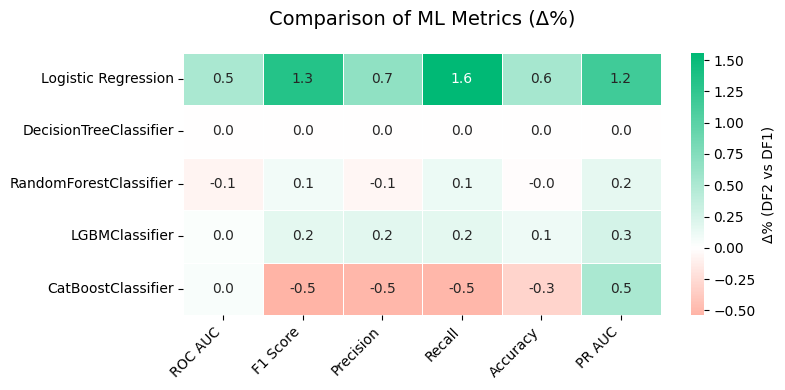

In [98]:
compare_metrics_heatmap(standard_scaler_del_metrics, normalised_metrics)

(<Figure size 800x400 with 2 Axes>,
                          ROC AUC  F1 Score  Precision    Recall  Accuracy  \
 Logistic Regression    -0.039272  0.193715   0.279555  0.145193  0.159414   
 DecisionTreeClassifier  0.000000  0.000000   0.000000  0.000000  0.000000   
 RandomForestClassifier  0.015940  0.240208   0.232713  0.236371  0.143754   
 LGBMClassifier         -0.027384 -0.627014   0.319940 -0.853536  0.071960   
 CatBoostClassifier      0.000000  0.000000   0.000000  0.000000  0.000000   
 
                           PR AUC  
 Logistic Regression    -0.167857  
 DecisionTreeClassifier  0.000000  
 RandomForestClassifier -0.002981  
 LGBMClassifier         -0.001840  
 CatBoostClassifier      0.000000  )

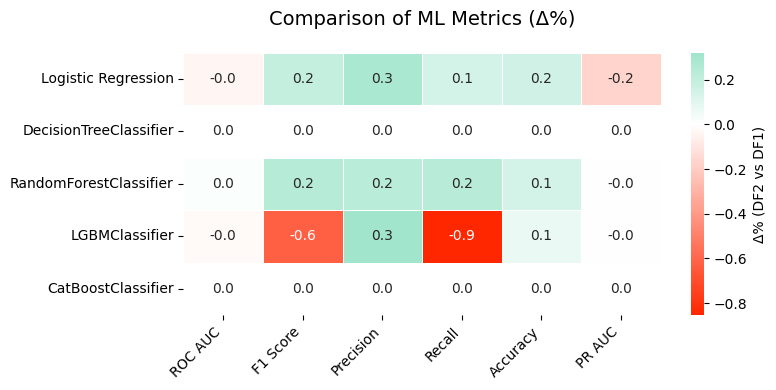

In [97]:
compare_metrics_heatmap(initial_metrics, normalised_metrics)

Замена на MinMaxScaler не улучшило метрики существенно

### 2.7 Замена OrdinalEncoder на CatBoostEncoder для всех категориальных переменных

In [119]:
preprocessor_catboost_encoding = clone(preprocessor)
del preprocessor_catboost_encoding.transformers[1]

preprocessor_catboost_encoding.transformers[1] = ("catboost_categorical", CatBoostEncoder(
                cols=CATEGORICAL_FEATURES_LIST,
                sigma=None,
                a=1.0,
                handle_unknown="value",
                handle_missing="value",
                random_state=42,), CATEGORICAL_FEATURES_LIST)

[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000467 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4664
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000670 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4664
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
[LightGBM] [Info] 

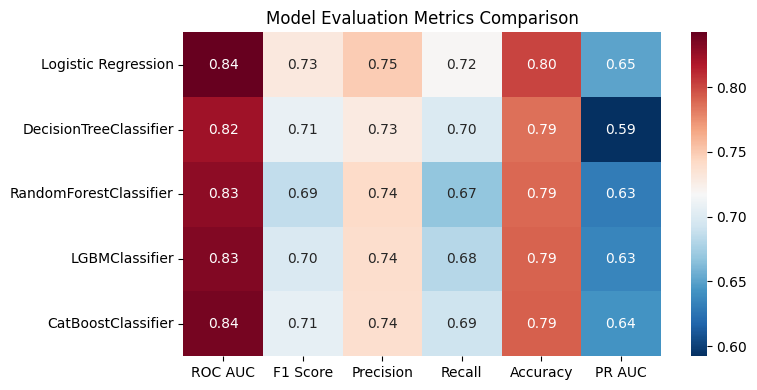

In [120]:
catboost_encoder_metrics = train_evaluate_models_cv(
    models=models,
    X=X,
    y=y,
    preprocessor=preprocessor_catboost_encoding,
    cv=cv,
    seed=SEED
)

(<Figure size 800x400 with 2 Axes>,
                          ROC AUC  F1 Score  Precision    Recall  Accuracy  \
 Logistic Regression    -0.133454  0.170789   0.151139  0.173708  0.070940   
 DecisionTreeClassifier -0.341831  0.043451  -0.031860  0.154259 -0.054156   
 RandomForestClassifier -0.372666 -2.416053   1.001392 -2.946408 -0.054056   
 LGBMClassifier         -0.105485 -1.541412   1.004389 -2.229720  0.161817   
 CatBoostClassifier     -0.234900 -0.062448  -0.372353  0.106874 -0.179030   
 
                           PR AUC  
 Logistic Regression    -0.454448  
 DecisionTreeClassifier -0.569882  
 RandomForestClassifier -1.266442  
 LGBMClassifier         -0.989945  
 CatBoostClassifier     -1.287251  )

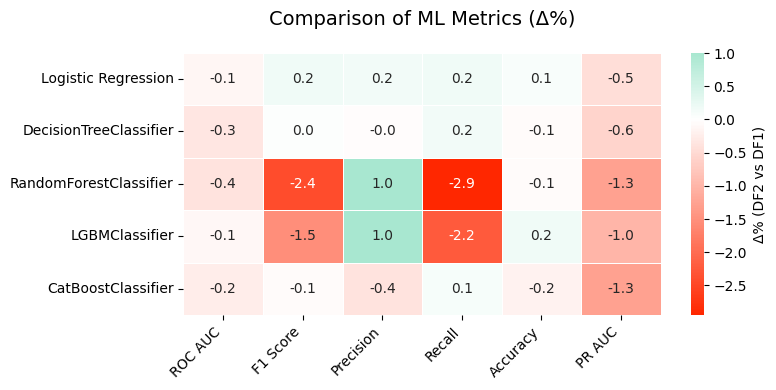

In [121]:
compare_metrics_heatmap(initial_metrics, catboost_encoder_metrics)

Метрики ухудшились

### 2.8 Работа с дисбалансом классов

#### 2.8.1 На уровне моделей

In [122]:
models_balanced = [
    ('Logistic Regression', LogisticRegression(random_state=SEED, max_iter=1000, solver='liblinear', class_weight='balanced')),
    ('DecisionTreeClassifier', DecisionTreeClassifier(random_state=SEED, max_depth=4, class_weight='balanced')),
    ('RandomForestClassifier', RandomForestClassifier(random_state=SEED, class_weight='balanced')),
    ('LGBMClassifier', LGBMClassifier(random_state=SEED, class_weight='balanced')),
    ('CatBoostClassifier', CatBoostClassifier(random_state=SEED, verbose=0, task_type="CPU", allow_writing_files=False, auto_class_weights='Balanced'))
]

[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001002 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1383
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000310 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1383
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 19
[LightGBM] [Info] [binary:

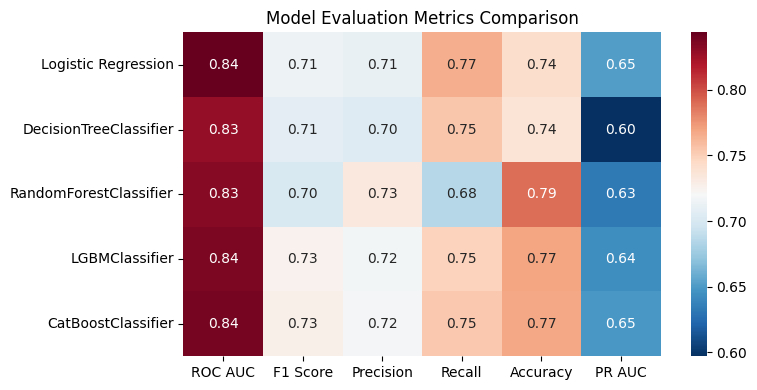

In [123]:
balanced_metrics = train_evaluate_models_cv(
    models=models_balanced,
    X=X,
    y=y,
    preprocessor=preprocessor,
    cv=cv,
    seed=SEED
)

(<Figure size 800x400 with 2 Axes>,
                          ROC AUC  F1 Score  Precision    Recall  Accuracy  \
 Logistic Regression     0.013178 -2.009283  -4.841814  6.719822 -7.457641   
 DecisionTreeClassifier  0.316996 -0.079629  -3.270390  8.114245 -6.247483   
 RandomForestClassifier  0.026914 -0.414534  -0.027885 -0.478000 -0.071973   
 LGBMClassifier          0.317762  2.410230  -2.121816  7.414550 -2.658754   
 CatBoostClassifier     -0.038580  2.978934  -3.190022  9.111040 -3.308191   
 
                           PR AUC  
 Logistic Regression    -0.195065  
 DecisionTreeClassifier  0.252355  
 RandomForestClassifier -0.996463  
 LGBMClassifier          0.340457  
 CatBoostClassifier     -0.323608  )

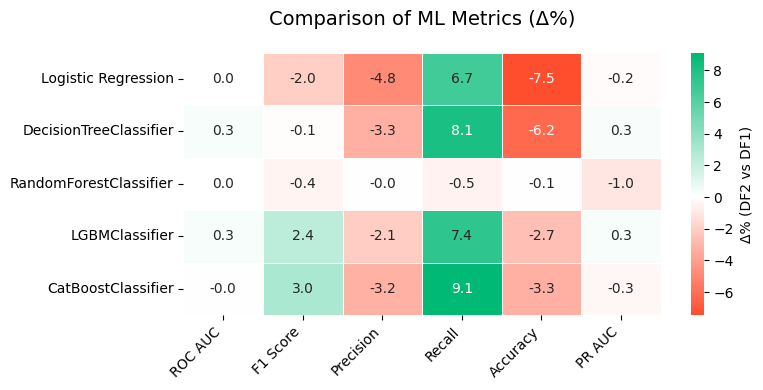

In [124]:
compare_metrics_heatmap(initial_metrics, balanced_metrics)

У всех моделей, кроме Случайного леса, значительно улучшился Recall, но снизился Precision

#### 2.8.2 SMOTE

In [125]:
preprocessor_pipeline = Pipeline([("transformations", preprocessor)])
preprocessor_pipeline.set_output(transform="pandas")

,steps,"[('transformations', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('scaler_numerical', ...), ('ordinal_categorical', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


In [126]:
preprocessor_pipeline_smote = clone(preprocessor_pipeline)

preprocessor_pipeline_smote.steps.append(
    ('smote', SMOTE(random_state=SEED))
)

[LightGBM] [Info] Number of positive: 4139, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000763 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1564
[LightGBM] [Info] Number of data points in the train set: 8278, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 4139, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000448 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1564
[LightGBM] [Info] Number of data points in the train set: 8278, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


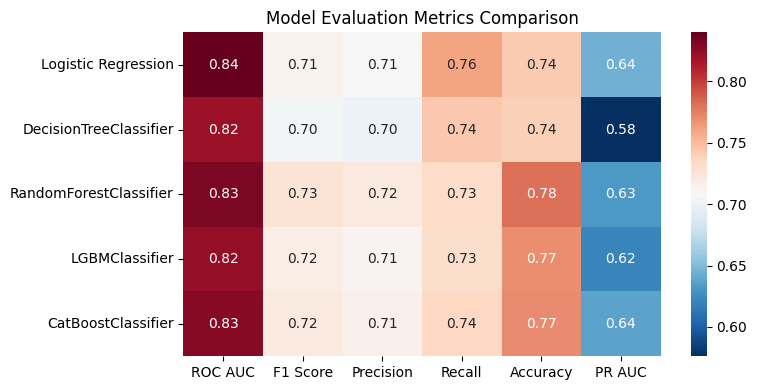

In [127]:
smote_metrics = train_evaluate_models_cv(
    models=models,
    X=X,
    y=y,
    preprocessor=preprocessor_pipeline_smote,
    cv=cv,
    seed=SEED
)

(<Figure size 800x400 with 2 Axes>,
                          ROC AUC  F1 Score  Precision    Recall  Accuracy  \
 Logistic Regression    -0.451503 -2.187507  -5.185316  6.079131 -7.422485   
 DecisionTreeClassifier -0.485709 -0.470033  -3.857103  6.543940 -5.994755   
 RandomForestClassifier -0.009124  3.211900  -1.697170  6.607438 -1.204213   
 LGBMClassifier         -1.150199  1.245705  -2.829516  4.896314 -2.712268   
 CatBoostClassifier     -1.279252  1.998623  -3.644829  6.373300 -2.950181   
 
                           PR AUC  
 Logistic Regression    -1.325886  
 DecisionTreeClassifier -3.245030  
 RandomForestClassifier -0.837095  
 LGBMClassifier         -3.223298  
 CatBoostClassifier     -2.109307  )

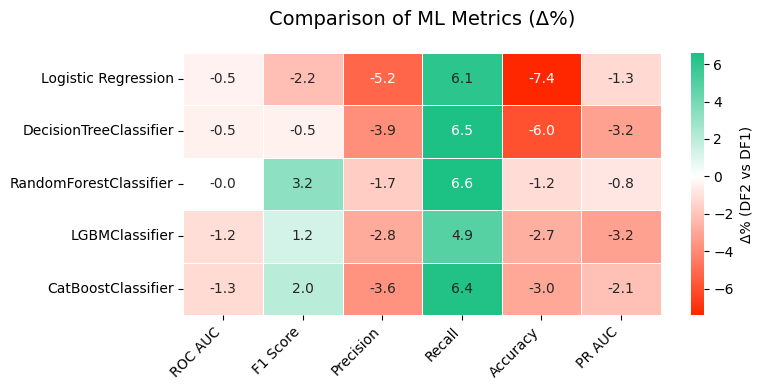

In [128]:
compare_metrics_heatmap(initial_metrics, smote_metrics)

У всех моделей существенно улучшился Recall, но уменьшился Precision

### 2.10 Комбинации лучших преобразований

Попробуем проверить комбинации лучших преобразований:
1. Логарифмирование **TotalCharges** без удаления
2. Биннинг **tenure** без удаления
3. Биннинг **MonthlyCharges** без удаления

Также применить работу с дисбалансом классов на уровне модели


In [ ]:
# Функция для удобного перебора вариантов выбранных комбинаций
def transform_combinations(transform_choice, X, y, preprocessor, models):
    X_final = X.copy()
    preprocessor_final = clone(preprocessor)
    if 1 in transform_choice:
        X_final["TotalChargesLog"] = np.log1p(X_final["TotalCharges"])
        preprocessor_final.transformers[0][2].append("TotalChargesLog")
    if 2 in transform_choice:
        bins = [-np.inf, 12, 60, np.inf]
        labels = [0, 1, 2]
        X_final["tenure_bins"] = pd.cut(
            X_final["tenure"], bins=bins, labels=labels
        ).astype(int)
    if 3 in transform_choice:
        bins = [-np.inf, 30, 70, np.inf]
        labels = [0, 1, 2]
        X_final["monthly_charges_bins"] = pd.cut(
            X_final["MonthlyCharges"], bins=bins, labels=labels
        ).astype(int)

    final_metrics = train_evaluate_models_cv(
        models=models,
        X=X_final,
        y=y,
        preprocessor=preprocessor_final,
        cv=cv,
        seed=SEED,
    )
    return X_final, preprocessor_final, final_metrics

#### 2.10.1 Без работы с дисбалансом

##### 2.10.1.1 Преобразования 1 + 2

[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000222 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1641
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000537 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1641
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGB

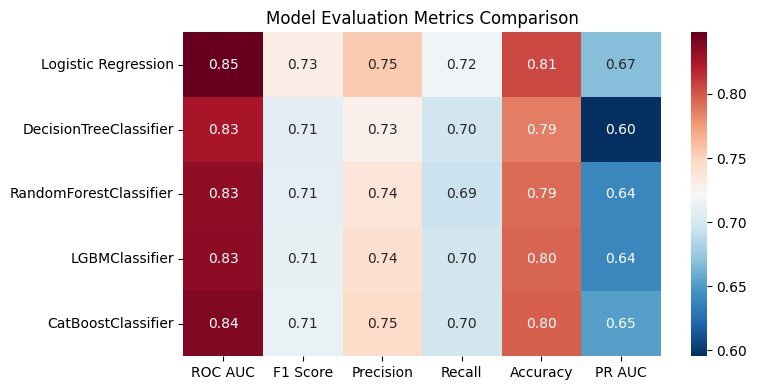

In [157]:
X_final_1_2, preprocessor_final_1_2, final_metrics_1_2 = transform_combinations(
    [1, 2], X, y, preprocessor, models
)

(<Figure size 800x400 with 2 Axes>,
                          ROC AUC  F1 Score  Precision    Recall  Accuracy  \
 Logistic Regression     0.523081  0.297880   0.898327  0.004536  0.442972   
 DecisionTreeClassifier  0.000000  0.000000   0.000000  0.000000  0.000000   
 RandomForestClassifier  0.197257  0.873375   0.594845  0.906060  0.395211   
 LGBMClassifier          0.112782  0.464118   1.360786  0.146021  0.664781   
 CatBoostClassifier     -0.002490  0.965469   0.649774  0.954506  0.429216   
 
                           PR AUC  
 Logistic Regression     2.214769  
 DecisionTreeClassifier  0.000000  
 RandomForestClassifier  0.222607  
 LGBMClassifier         -0.265984  
 CatBoostClassifier      0.124955  )

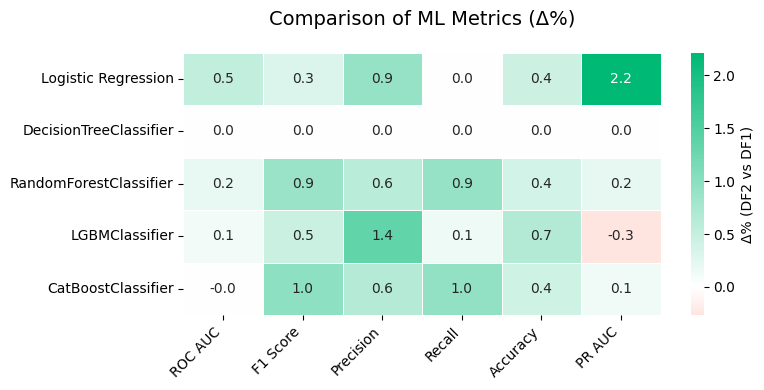

In [158]:
compare_metrics_heatmap(initial_metrics, final_metrics_1_2)

##### 2.10.1.2 Преобразования 1 + 3

[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000641 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1641
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000858 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1641
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
[LightGBM] [Info] 

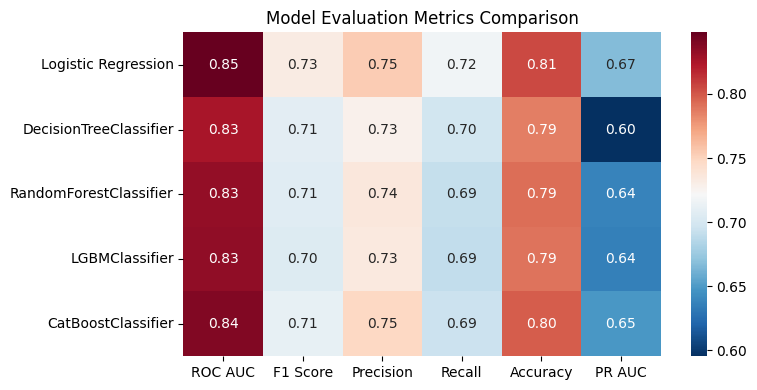

In [159]:
X_final_1_3, preprocessor_final_1_3, final_metrics_1_3 = transform_combinations(
    [1, 3], X, y, preprocessor, models
)

(<Figure size 800x400 with 2 Axes>,
                          ROC AUC  F1 Score  Precision    Recall  Accuracy  \
 Logistic Regression     0.525389  0.353030   0.866612  0.099643  0.443073   
 DecisionTreeClassifier  0.000000  0.000000   0.000000  0.000000  0.000000   
 RandomForestClassifier  0.042521  0.518320   0.336615  0.530639  0.233451   
 LGBMClassifier          0.016604 -0.574102   0.337342 -0.865636  0.053973   
 CatBoostClassifier      0.008785  0.704878   0.926897  0.564957  0.500777   
 
                           PR AUC  
 Logistic Regression     2.080646  
 DecisionTreeClassifier  0.000000  
 RandomForestClassifier -0.041320  
 LGBMClassifier         -0.862402  
 CatBoostClassifier     -0.363720  )

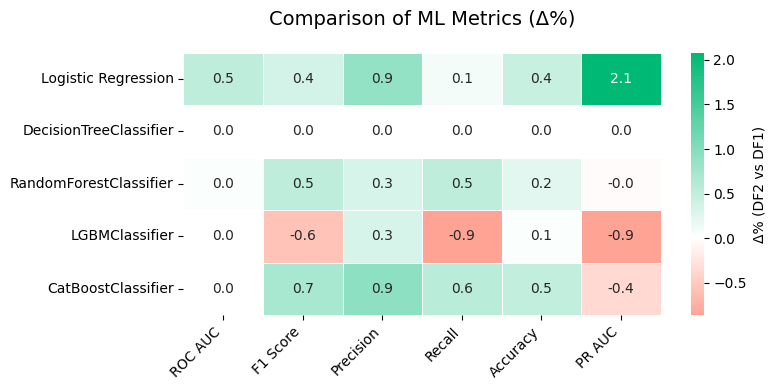

In [160]:
compare_metrics_heatmap(initial_metrics, final_metrics_1_3)

##### 2.10.1.3 Преобразования 2 + 3

[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000285 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1389
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000254 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1389
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 21
[LightGBM] [Info] [binar

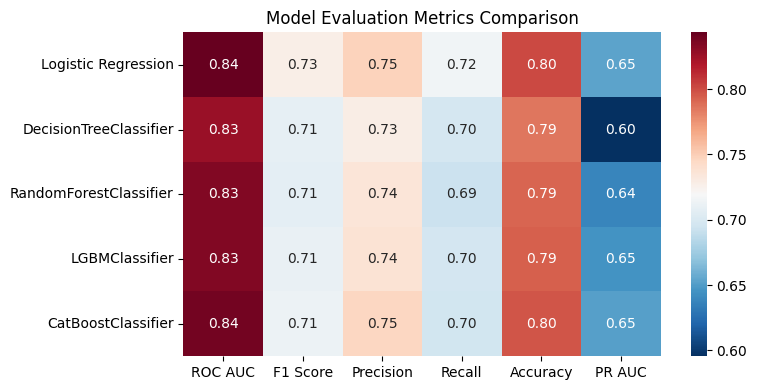

In [161]:
X_final_2_3, preprocessor_final_2_3, final_metrics_2_3 = transform_combinations(
    [2, 3], X, y, preprocessor, models
)

(<Figure size 800x400 with 2 Axes>,
                          ROC AUC  F1 Score  Precision    Recall  Accuracy  \
 Logistic Regression    -0.012215 -0.163519   0.055843 -0.274973 -0.017634   
 DecisionTreeClassifier  0.000000  0.000000   0.000000  0.000000  0.000000   
 RandomForestClassifier  0.308028  0.612601   0.257044  0.690506  0.215548   
 LGBMClassifier          0.105384  0.252871   0.767124 -0.002673  0.377364   
 CatBoostClassifier      0.066095  0.777512   0.673391  0.742402  0.411300   
 
                           PR AUC  
 Logistic Regression    -0.028373  
 DecisionTreeClassifier  0.000000  
 RandomForestClassifier -0.047656  
 LGBMClassifier          0.693411  
 CatBoostClassifier      0.089446  )

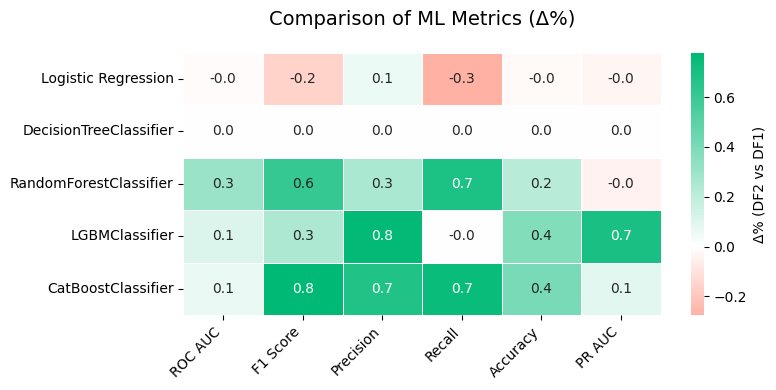

In [162]:
compare_metrics_heatmap(initial_metrics, final_metrics_2_3)

##### 2.10.1.4 Преобразования 1 + 2 + 3

[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000305 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1644
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000415 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1644
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 22
[LightGBM] [Info] [binar

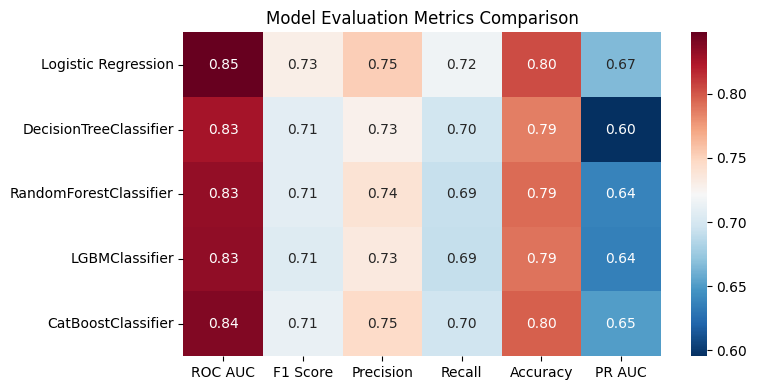

In [163]:
X_final_1_2_3, preprocessor_final_1_2_3, final_metrics_1_2_3 = transform_combinations(
    [1, 2, 3], X, y, preprocessor, models
)

(<Figure size 800x400 with 2 Axes>,
                          ROC AUC  F1 Score  Precision    Recall  Accuracy  \
 Logistic Regression     0.503629  0.178700   0.706916 -0.076455  0.336789   
 DecisionTreeClassifier  0.000000  0.000000   0.000000  0.000000  0.000000   
 RandomForestClassifier  0.019864  0.722599   0.772877  0.674153  0.449229   
 LGBMClassifier          0.031897 -0.509126   0.256801 -0.746312  0.018076   
 CatBoostClassifier      0.023188  0.818941   0.651785  0.767472  0.411326   
 
                           PR AUC  
 Logistic Regression     2.022251  
 DecisionTreeClassifier  0.000000  
 RandomForestClassifier -0.117769  
 LGBMClassifier         -0.864416  
 CatBoostClassifier      0.001921  )

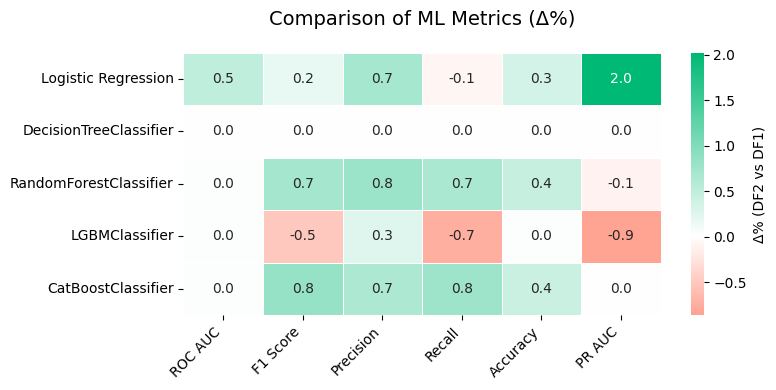

In [164]:
compare_metrics_heatmap(initial_metrics, final_metrics_1_2_3)

##### 2.10.1.5 Результаты сравнения

(<Figure size 800x400 with 2 Axes>,
                          ROC AUC  F1 Score  Precision    Recall  Accuracy  \
 Logistic Regression    -0.532510 -0.460029  -0.834984 -0.279496 -0.458575   
 DecisionTreeClassifier  0.000000  0.000000   0.000000  0.000000  0.000000   
 RandomForestClassifier  0.110553 -0.258515  -0.335804 -0.213618 -0.178956   
 LGBMClassifier         -0.007390 -0.210271  -0.585692 -0.148477 -0.285519   
 CatBoostClassifier      0.068587 -0.186160   0.023464 -0.210099 -0.017839   
 
                           PR AUC  
 Logistic Regression    -2.194539  
 DecisionTreeClassifier  0.000000  
 RandomForestClassifier -0.269663  
 LGBMClassifier          0.961954  
 CatBoostClassifier     -0.035465  )

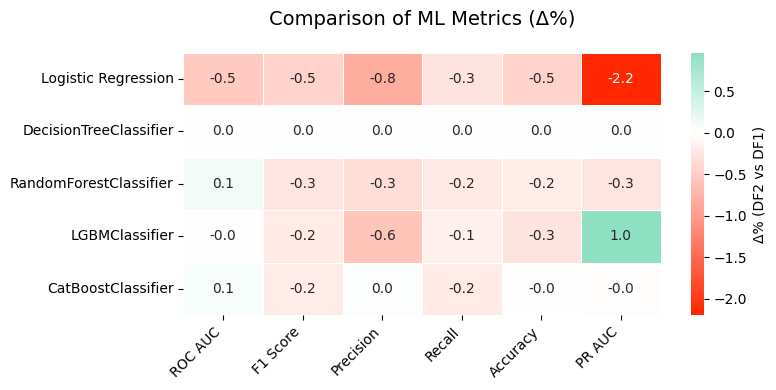

In [165]:
compare_metrics_heatmap(final_metrics_1_2, final_metrics_2_3)

Комбинация **1 + 2** лучше чем **2 + 3**

(<Figure size 800x400 with 2 Axes>,
                          ROC AUC  F1 Score  Precision    Recall  Accuracy  \
 Logistic Regression     0.002296  0.054986  -0.031432  0.095103  0.000100   
 DecisionTreeClassifier  0.000000  0.000000   0.000000  0.000000  0.000000   
 RandomForestClassifier -0.154431 -0.351980  -0.256703 -0.372050 -0.161123   
 LGBMClassifier         -0.096070 -1.033424  -1.009703 -1.010182 -0.606774   
 CatBoostClassifier      0.011276 -0.258099   0.275333 -0.385866  0.071256   
 
                           PR AUC  
 Logistic Regression    -0.131217  
 DecisionTreeClassifier  0.000000  
 RandomForestClassifier -0.263341  
 LGBMClassifier         -0.598009  
 CatBoostClassifier     -0.488065  )

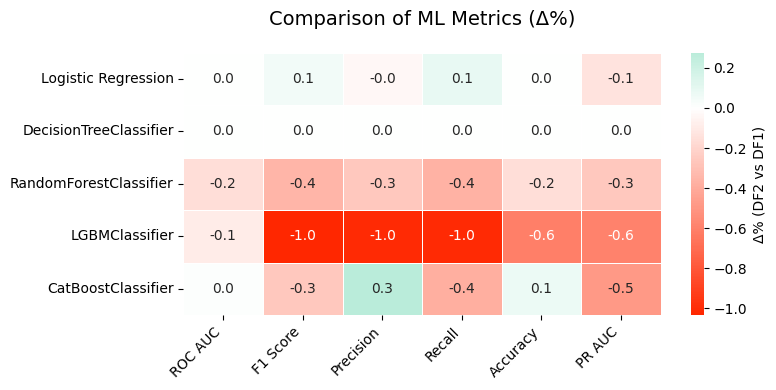

In [166]:
compare_metrics_heatmap(final_metrics_1_2, final_metrics_1_3)

Комбинация **1 + 2** лучше чем **1 + 3**

(<Figure size 800x400 with 2 Axes>,
                          ROC AUC  F1 Score  Precision    Recall  Accuracy  \
 Logistic Regression     0.537669  0.517395   0.810317  0.375649  0.460789   
 DecisionTreeClassifier  0.000000  0.000000   0.000000  0.000000  0.000000   
 RandomForestClassifier -0.264692 -0.093707   0.079367 -0.158771  0.017865   
 LGBMClassifier         -0.088687 -0.824888  -0.426510 -0.862986 -0.322175   
 CatBoostClassifier     -0.057272 -0.072073   0.251810 -0.176137  0.089111   
 
                           PR AUC  
 Logistic Regression     2.109618  
 DecisionTreeClassifier  0.000000  
 RandomForestClassifier  0.006339  
 LGBMClassifier         -1.545099  
 CatBoostClassifier     -0.452761  )

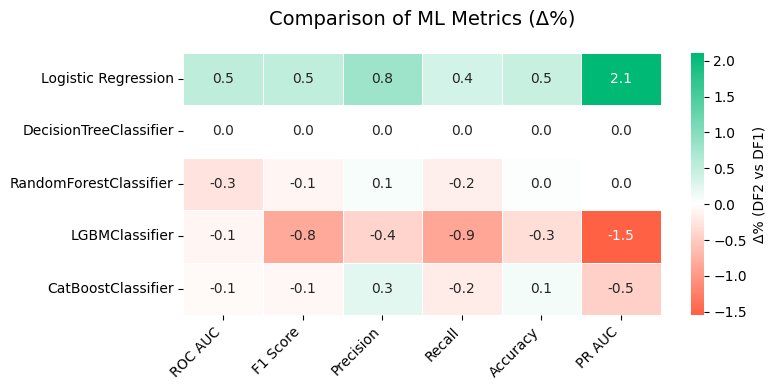

In [167]:
compare_metrics_heatmap(final_metrics_2_3, final_metrics_1_3)

Комбинация **2 + 3** лучше чем **1 + 3** в градиентных бустингах. В логистической регрессии наоборот

(<Figure size 800x400 with 2 Axes>,
                          ROC AUC  F1 Score  Precision    Recall  Accuracy  \
 Logistic Regression    -0.019351 -0.118827  -0.189707 -0.080988 -0.105715   
 DecisionTreeClassifier  0.000000  0.000000   0.000000  0.000000  0.000000   
 RandomForestClassifier -0.177044 -0.149470   0.176979 -0.229825  0.053805   
 LGBMClassifier         -0.080794 -0.968748  -1.089163 -0.891032 -0.642434   
 CatBoostClassifier      0.025679 -0.145127   0.001997 -0.185266 -0.017814   
 
                           PR AUC  
 Logistic Regression    -0.188347  
 DecisionTreeClassifier  0.000000  
 RandomForestClassifier -0.339620  
 LGBMClassifier         -0.600028  
 CatBoostClassifier     -0.122881  )

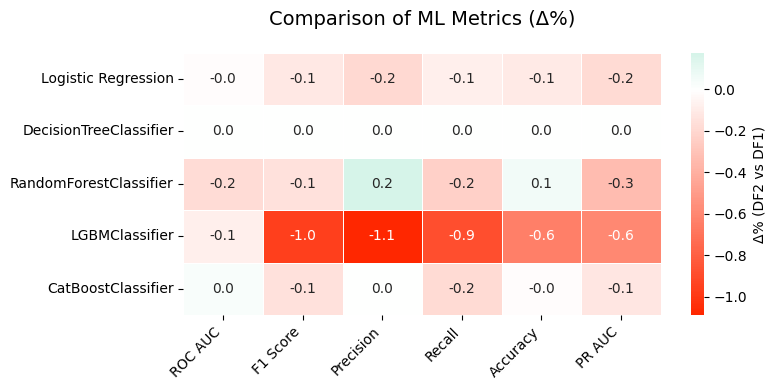

In [168]:
compare_metrics_heatmap(final_metrics_1_2, final_metrics_1_2_3)

Комбинация **1 + 2** лучше чем **1 + 2 + 3**

(<Figure size 800x400 with 2 Axes>,
                          ROC AUC  F1 Score  Precision    Recall  Accuracy  \
 Logistic Regression    -0.011039  0.051263   0.022728  0.061310  0.017622   
 DecisionTreeClassifier  0.000000  0.000000   0.000000  0.000000  0.000000   
 RandomForestClassifier  0.103414 -0.172839  -0.413489 -0.129921 -0.232170   
 LGBMClassifier          0.016981  0.058179   0.066639  0.052204  0.035723   
 CatBoostClassifier      0.014860  0.239964   0.061527  0.238829  0.053508   
 
                           PR AUC  
 Logistic Regression    -0.045734  
 DecisionTreeClassifier  0.000000  
 RandomForestClassifier  0.201646  
 LGBMClassifier          0.024407  
 CatBoostClassifier      0.087220  )

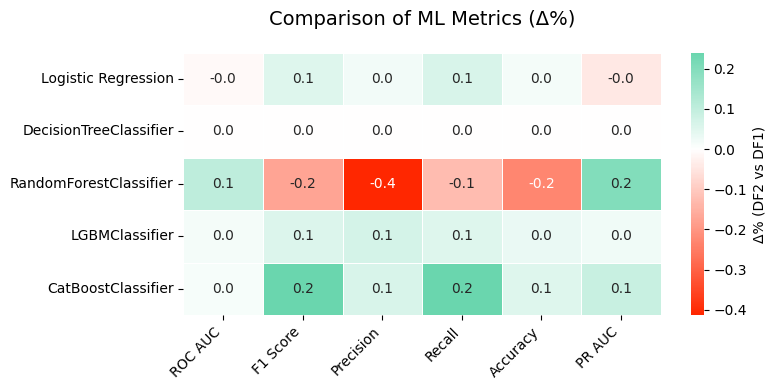

In [174]:
compare_metrics_heatmap(log_metrics, final_metrics_1_2)

Комбинация **1 + 2** лучше чем **1**

(<Figure size 800x400 with 2 Axes>,
                          ROC AUC  F1 Score  Precision    Recall  Accuracy  \
 Logistic Regression     0.495266  0.581577   1.008421  0.372370  0.549828   
 DecisionTreeClassifier  0.000000  0.000000   0.000000  0.000000  0.000000   
 RandomForestClassifier  0.032141 -0.184102  -0.347860 -0.138232 -0.178877   
 LGBMClassifier          0.112782  0.464118   1.360786  0.146021  0.664781   
 CatBoostClassifier      0.021551  0.222834  -0.213516  0.327073 -0.053400   
 
                           PR AUC  
 Logistic Regression     2.059057  
 DecisionTreeClassifier  0.000000  
 RandomForestClassifier  0.836196  
 LGBMClassifier         -0.265984  
 CatBoostClassifier      0.316715  )

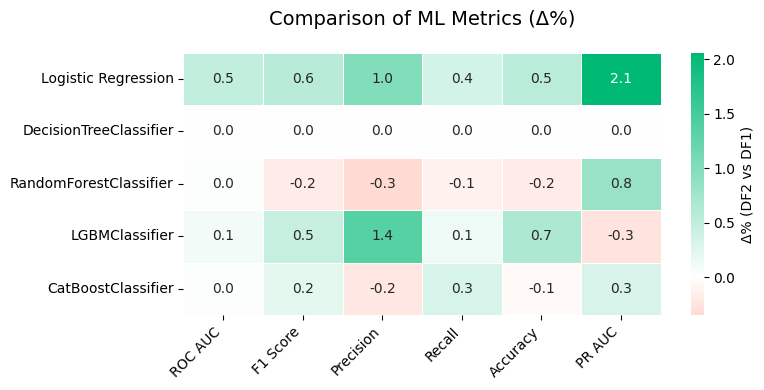

In [175]:
compare_metrics_heatmap(tenure_binning_metrics, final_metrics_1_2)

Комбинация **1 + 2** лучше чем **2**

(<Figure size 800x400 with 2 Axes>,
                          ROC AUC  F1 Score  Precision    Recall  Accuracy  \
 Logistic Regression     0.563914 -0.158459   0.486648 -0.457798  0.176780   
 DecisionTreeClassifier  0.000000  0.000000   0.000000  0.000000  0.000000   
 RandomForestClassifier -0.044115  0.277448   0.039249  0.363527  0.053630   
 LGBMClassifier          0.007452  0.210714   0.589142  0.148698  0.286337   
 CatBoostClassifier     -0.082625  0.707314   0.394050  0.741631  0.285659   
 
                           PR AUC  
 Logistic Regression     2.338109  
 DecisionTreeClassifier  0.000000  
 RandomForestClassifier  0.639492  
 LGBMClassifier         -0.952672  
 CatBoostClassifier      0.234554  )

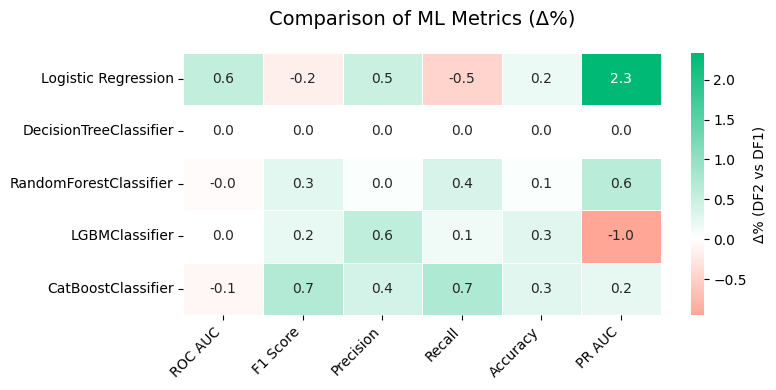

In [176]:
compare_metrics_heatmap(monthly_charges_binning_metrics, final_metrics_1_2)

Комбинация **1 + 2** лучше чем **3**

Самая удачная комбинация преобразований среди всех - **1 + 2**:
1. Логарифмирование **TotalCharges** без удаления
2. Биннинг **tenure** без удаления

#### 2.10.2 Работа с дисбалансом

Сравним комбинацию преобразований **1 + 2** вместе с работой с дисбалансом

In [169]:
models_balanced = [
    ('Logistic Regression', LogisticRegression(random_state=SEED, max_iter=1000, solver='liblinear', class_weight='balanced')),
    ('DecisionTreeClassifier', DecisionTreeClassifier(random_state=SEED, max_depth=4, class_weight='balanced')),
    ('RandomForestClassifier', RandomForestClassifier(random_state=SEED, class_weight='balanced')),
    ('LGBMClassifier', LGBMClassifier(random_state=SEED, class_weight='balanced')),
    ('CatBoostClassifier', CatBoostClassifier(random_state=SEED, verbose=0, task_type="CPU", allow_writing_files=False, auto_class_weights='Balanced'))
]

[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000399 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1641
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000337 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1641
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 21
[LightGBM] [Info] [binary:

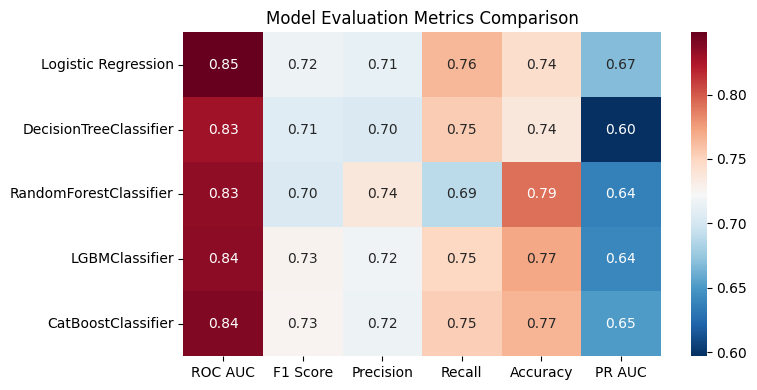

In [170]:
X_final_1_2_balanced, preprocessor_final_1_2_balanced, final_metrics_1_2_balanced = transform_combinations(
    [1, 2], X, y, preprocessor, models_balanced
)

(<Figure size 800x400 with 2 Axes>,
                          ROC AUC  F1 Score  Precision    Recall  Accuracy  \
 Logistic Regression     0.546286 -1.764116  -4.771650  6.655876 -7.103406   
 DecisionTreeClassifier  0.316996 -0.079629  -3.270390  8.114245 -6.247483   
 RandomForestClassifier  0.200100  0.137499   0.442544  0.044809  0.215624   
 LGBMClassifier          0.163951  2.613329  -1.977830  7.402009 -2.389298   
 CatBoostClassifier     -0.008088  2.714202  -3.431488  8.996716 -3.612137   
 
                           PR AUC  
 Logistic Regression     2.240824  
 DecisionTreeClassifier  0.252355  
 RandomForestClassifier -0.260510  
 LGBMClassifier         -0.099320  
 CatBoostClassifier      0.044796  )

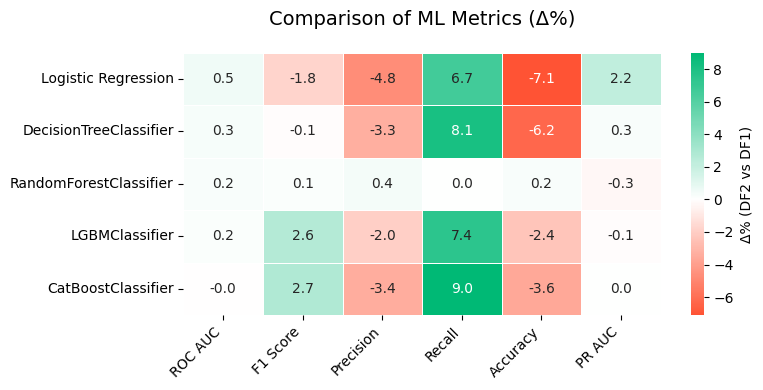

In [171]:
compare_metrics_heatmap(initial_metrics, final_metrics_1_2_balanced)

(<Figure size 800x400 with 2 Axes>,
                          ROC AUC  F1 Score  Precision    Recall  Accuracy  \
 Logistic Regression     0.023085 -2.055872  -5.619496  6.651038 -7.513098   
 DecisionTreeClassifier  0.316996 -0.079629  -3.270390  8.114245 -6.247483   
 RandomForestClassifier  0.002837 -0.729504  -0.151401 -0.853517 -0.178880   
 LGBMClassifier          0.051111  2.139282  -3.293794  7.245408 -3.033910   
 CatBoostClassifier     -0.005598  1.732011  -4.054915  7.966172 -4.024081   
 
                           PR AUC  
 Logistic Regression     0.025490  
 DecisionTreeClassifier  0.252355  
 RandomForestClassifier -0.482044  
 LGBMClassifier          0.167109  
 CatBoostClassifier     -0.080059  )

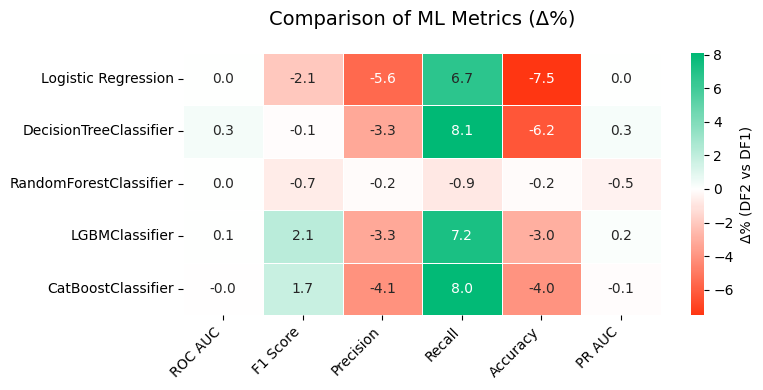

In [172]:
compare_metrics_heatmap(final_metrics_1_2, final_metrics_1_2_balanced)

При комбинации **1 + 2** и работе с дисбалансом существенно повышается **Recall**, но ожидаемо падает **Precision**.

**f1_score** немного вырос

**Roc_auc** и **pr_auc** не меняются

## 3. Результаты

Самая удачная комбинация преобразований среди всех - **1 + 2**:
1. Логарифмирование **TotalCharges** без удаления
2. Биннинг **tenure** без удаления

Также можно использовать работу с дисбалансом классов на уровне модели, так как наблюдается существенный рост **Recall** (9%) и небольшой рост **f1_score** (2.7%), несмотря на падение **Precision** (-3.4%)

In [177]:
X_final = X.copy()
preprocessor_final = clone(preprocessor)

In [178]:
X_final["TotalChargesLog"] = np.log1p(X_final["TotalCharges"])
preprocessor_final.transformers[0][2].append("TotalChargesLog")


bins = [-np.inf, 12, 60, np.inf]
labels = [0, 1, 2]
X_final["tenure_bins"] = pd.cut(X_final["tenure"], bins=bins, labels=labels).astype(int)

[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001112 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1641
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000547 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1641
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] 

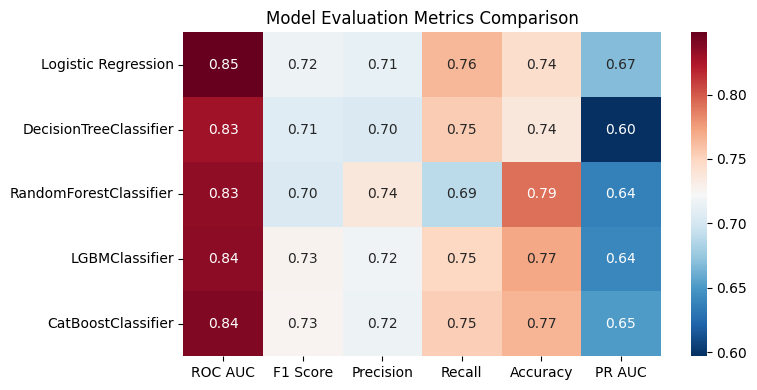

In [179]:
final_metrics = train_evaluate_models_cv(
    models=models_balanced,
    X=X_final,
    y=y,
    preprocessor=preprocessor_final,
    cv=cv,
    seed=SEED,
)

(<Figure size 800x400 with 2 Axes>,
                          ROC AUC  F1 Score  Precision    Recall  Accuracy  \
 Logistic Regression     0.546286 -1.764116  -4.771650  6.655876 -7.103406   
 DecisionTreeClassifier  0.316996 -0.079629  -3.270390  8.114245 -6.247483   
 RandomForestClassifier  0.200100  0.137499   0.442544  0.044809  0.215624   
 LGBMClassifier          0.163951  2.613329  -1.977830  7.402009 -2.389298   
 CatBoostClassifier     -0.008088  2.714202  -3.431488  8.996716 -3.612137   
 
                           PR AUC  
 Logistic Regression     2.240824  
 DecisionTreeClassifier  0.252355  
 RandomForestClassifier -0.260510  
 LGBMClassifier         -0.099320  
 CatBoostClassifier      0.044796  )

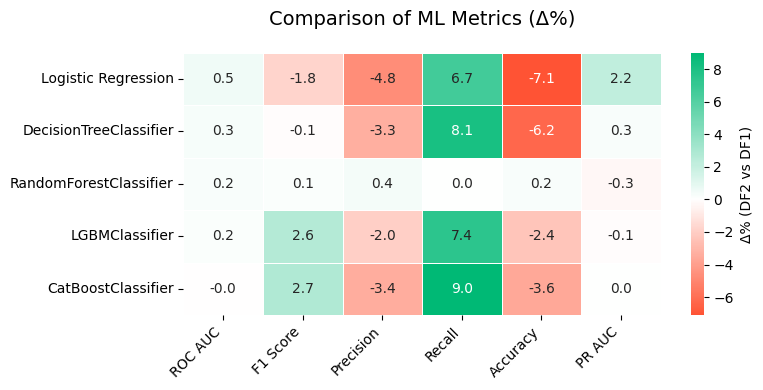

In [180]:
compare_metrics_heatmap(initial_metrics, final_metrics)

Лучше всего, по метрикам, себя показали **Логистическая регрессия** и **CatBoost**.

Логистическая регрессия:

- Даёт чуть лучшее качество
- Простая, линейная, легко интерпретируемая модель
- По важности признаков главным фактором она считает tenure (количество месяцев с компанией)
- Скорее всего, эта модель уже близка к максимуму возможного качества, так как линейные модели имеют ограниченное пространство гиперпараметров и слабую способность улавливать нелинейные зависимости между признаками

CatBoost:

- Даёт немного хуже метрики без тюнинга гиперпараметров
- Нелинейная модель, умеет находить сложные взаимодействия между признаками
- Основной важный признак - Contract, что логично, поскольку тип контракта часто сильно влияет на отток
- Потенциал улучшения значительно выше при корректном подборе гиперпараметров (learning rate, depth, l2_leaf_reg, subsample, rsm и т.д.)

Исходя из этого, для дальнейшего подбора гиперпараметров была выбрана модель Catboost.